In [1]:
import torch
import torchvision
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.io.image import decode_image
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection import _utils
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision

import sys, os
sys.path.append(os.path.abspath('..'))
from CustomDataset import CustomDataset

### Data

In [2]:
## TRAIN DATALOADER
train_image_dir = "../data/mobile detection.v7i.yolov11/train/images"
train_annotation_dir = "../data/mobile detection.v7i.yolov11/train/labels"
train_annotations = os.listdir(train_annotation_dir)

train_dataset = CustomDataset(train_image_dir, 
                              train_annotations, 
                              train_annotation_dir, 
                              transform=transforms.ToTensor())

train_data_loader = DataLoader(train_dataset, 
                               batch_size=4, 
                               shuffle=True, 
                               collate_fn=lambda x: tuple(zip(*x)))

## VAL DATALOADER
val_image_dir = "../data/mobile detection.v7i.yolov11/valid/images"
val_annotation_dir = "../data/mobile detection.v7i.yolov11/valid/labels"
val_annotations = os.listdir(val_annotation_dir)

val_dataset = CustomDataset(val_image_dir, 
                              val_annotations, 
                              val_annotation_dir, 
                              transform=transforms.ToTensor())

val_data_loader = DataLoader(val_dataset, 
                               batch_size=4, 
                               shuffle=False, 
                               collate_fn=lambda x: tuple(zip(*x)))



## Faster-RCNN Model

In [ ]:
num_classes = 4 

## get the pretrained backbone model
weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(weights=weights)

print(model)

# Replace the classification head
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes + 1)


for param in model.backbone.parameters():
    param.requires_grad = True


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

In [4]:
model

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

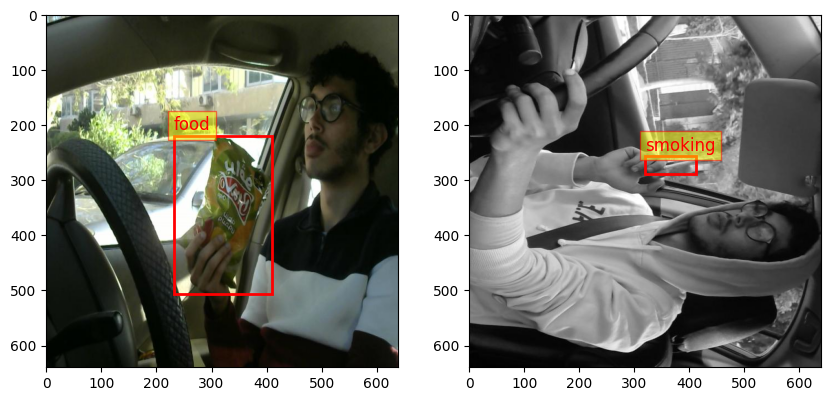

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create the plot
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax = ax.ravel()

# Get a batch of images and targets from the data loader
data_loader_iter = iter(train_data_loader)
images, targets = next(data_loader_iter)


class_names = ['background', 'water', 'food', 'phone', 'smoking']

# Plot the images with bounding boxes
for idx in range(2):
    image = images[idx].permute(1, 2, 0).numpy()  # Convert from (C, H, W) to (H, W, C) for visualization
    target = targets[idx]
    boxes = target["boxes"].numpy()
    labels = target["labels"].numpy()

    ax[idx].imshow(image)

    # Add bounding boxes to the image
    for box, label in zip(boxes, labels):
        xmin, ymin, xmax, ymax = box
        width, height = xmax - xmin, ymax - ymin
        rect = patches.Rectangle(
            (xmin, ymin),
            width,
            height,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax[idx].add_patch(rect)
        ax[idx].text(
            xmin,
            ymin - 10,
            f"{class_names[label]}",
            color="red",
            fontsize=12,
            bbox=dict(facecolor="yellow", alpha=0.5, edgecolor="red"),
        )

# Display the image with bounding boxes
plt.show()

In [6]:
# Step 5: Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
num_epochs = 10



In [7]:
metric = MeanAveragePrecision().to(device)
train_loss = []
val_loss = []
log_interval = 100


def to_device(obj, device=device):
    if torch.is_tensor(obj):
        return obj.to(device)
    if isinstance(obj, (list, tuple)):
        return [to_device(x, device) for x in obj]
    if isinstance(obj, dict):
        return {k: to_device(v, device) for k, v in obj.items()}
    return obj


for epoch in range(num_epochs):

    print(f'Starting the trainig of Epoch_{epoch+1}.....')
    print('Training...')

    model.train()
    train_running_loss = 0

    print(f'Epoch {epoch+1}/{num_epochs} training')


    for i, (images, targets) in enumerate(train_data_loader):
        # images = list(image.to(device) for image in images)
        # targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        images = to_device(images)
        targets = to_device(targets)

        # Forward pass
        loss_dict = model(images, targets)

        losses = sum(loss for loss in loss_dict.values())
        # loss_classifier → Measures how well the model classifies objects into correct categories.
        # loss_box_reg → Evaluates how accurately the predicted bounding boxes match the ground truth.
        # loss_objectness → Checks how confident the model is in detecting objects versus background.
        # loss_rpn_box_reg →
        
        # Backward pass
        optimizer.zero_grad() ## converting gradient value to zero for per batch
        losses.backward() ## compute the gradient
        optimizer.step() ## update the weights

        train_running_loss += losses.item()


    scheduler.step()

    model.eval()
    metric.reset()
    with torch.no_grad():
        for i, vdata in enumerate(val_data_loader):
            vinputs, vlabels = to_device(vdata, device)  
            voutputs = model(vinputs)
            # vloss = loss_fn(voutputs, vlabels)
            # running_vloss += vloss
            metric.update(voutputs, vlabels)

    val_MAP = metric.compute()
    train_loss.append(train_running_loss)
    print(f"Train_Loss: {train_running_loss/len(train_dataset):.4f}, mAP valid {val_MAP["map"].item():.4f}")
    print('\n')


Starting the trainig of Epoch_1.....
Training...
Epoch 1/10 training
Train_Loss: 0.0479, mAP valid 0.4552


Starting the trainig of Epoch_2.....
Training...
Epoch 2/10 training
Train_Loss: 0.0281, mAP valid 0.5131


Starting the trainig of Epoch_3.....
Training...
Epoch 3/10 training
Train_Loss: 0.0225, mAP valid 0.5271


Starting the trainig of Epoch_4.....
Training...
Epoch 4/10 training
Train_Loss: 0.0188, mAP valid 0.5390


Starting the trainig of Epoch_5.....
Training...
Epoch 5/10 training
Train_Loss: 0.0162, mAP valid 0.5393


Starting the trainig of Epoch_6.....
Training...
Epoch 6/10 training
Train_Loss: 0.0135, mAP valid 0.5517


Starting the trainig of Epoch_7.....
Training...
Epoch 7/10 training
Train_Loss: 0.0128, mAP valid 0.5585


Starting the trainig of Epoch_8.....
Training...
Epoch 8/10 training
Train_Loss: 0.0123, mAP valid 0.5586


Starting the trainig of Epoch_9.....
Training...
Epoch 9/10 training
Train_Loss: 0.0119, mAP valid 0.5613


Starting the trainig of Epoc

In [8]:
torch.save(model.state_dict(), "fasterRCNN.pth")

{'boxes': tensor([[165.0524, 314.6872, 286.2996, 633.6846]], device='cuda:0'), 'labels': tensor([2], device='cuda:0'), 'scores': tensor([0.9994], device='cuda:0')}
{'boxes': tensor([[173.8279, 357.4140, 345.8703, 634.2849]], device='cuda:0'), 'labels': tensor([2], device='cuda:0'), 'scores': tensor([0.9992], device='cuda:0')}
{'boxes': tensor([[164.2148, 183.3477, 302.2248, 602.8740],
        [156.0159, 196.5459, 293.7036, 519.7905]], device='cuda:0'), 'labels': tensor([1, 2], device='cuda:0'), 'scores': tensor([0.9989, 0.0594], device='cuda:0')}
{'boxes': tensor([], device='cuda:0', size=(0, 4)), 'labels': tensor([], device='cuda:0', dtype=torch.int64), 'scores': tensor([], device='cuda:0')}
{'boxes': tensor([[350.1404, 147.9580, 432.8008, 259.6812]], device='cuda:0'), 'labels': tensor([1], device='cuda:0'), 'scores': tensor([0.9993], device='cuda:0')}
{'boxes': tensor([[442.8893, 355.3392, 513.9387, 470.8348],
        [  8.6746, 164.6935,  87.7416, 316.4710]], device='cuda:0'), 'labe

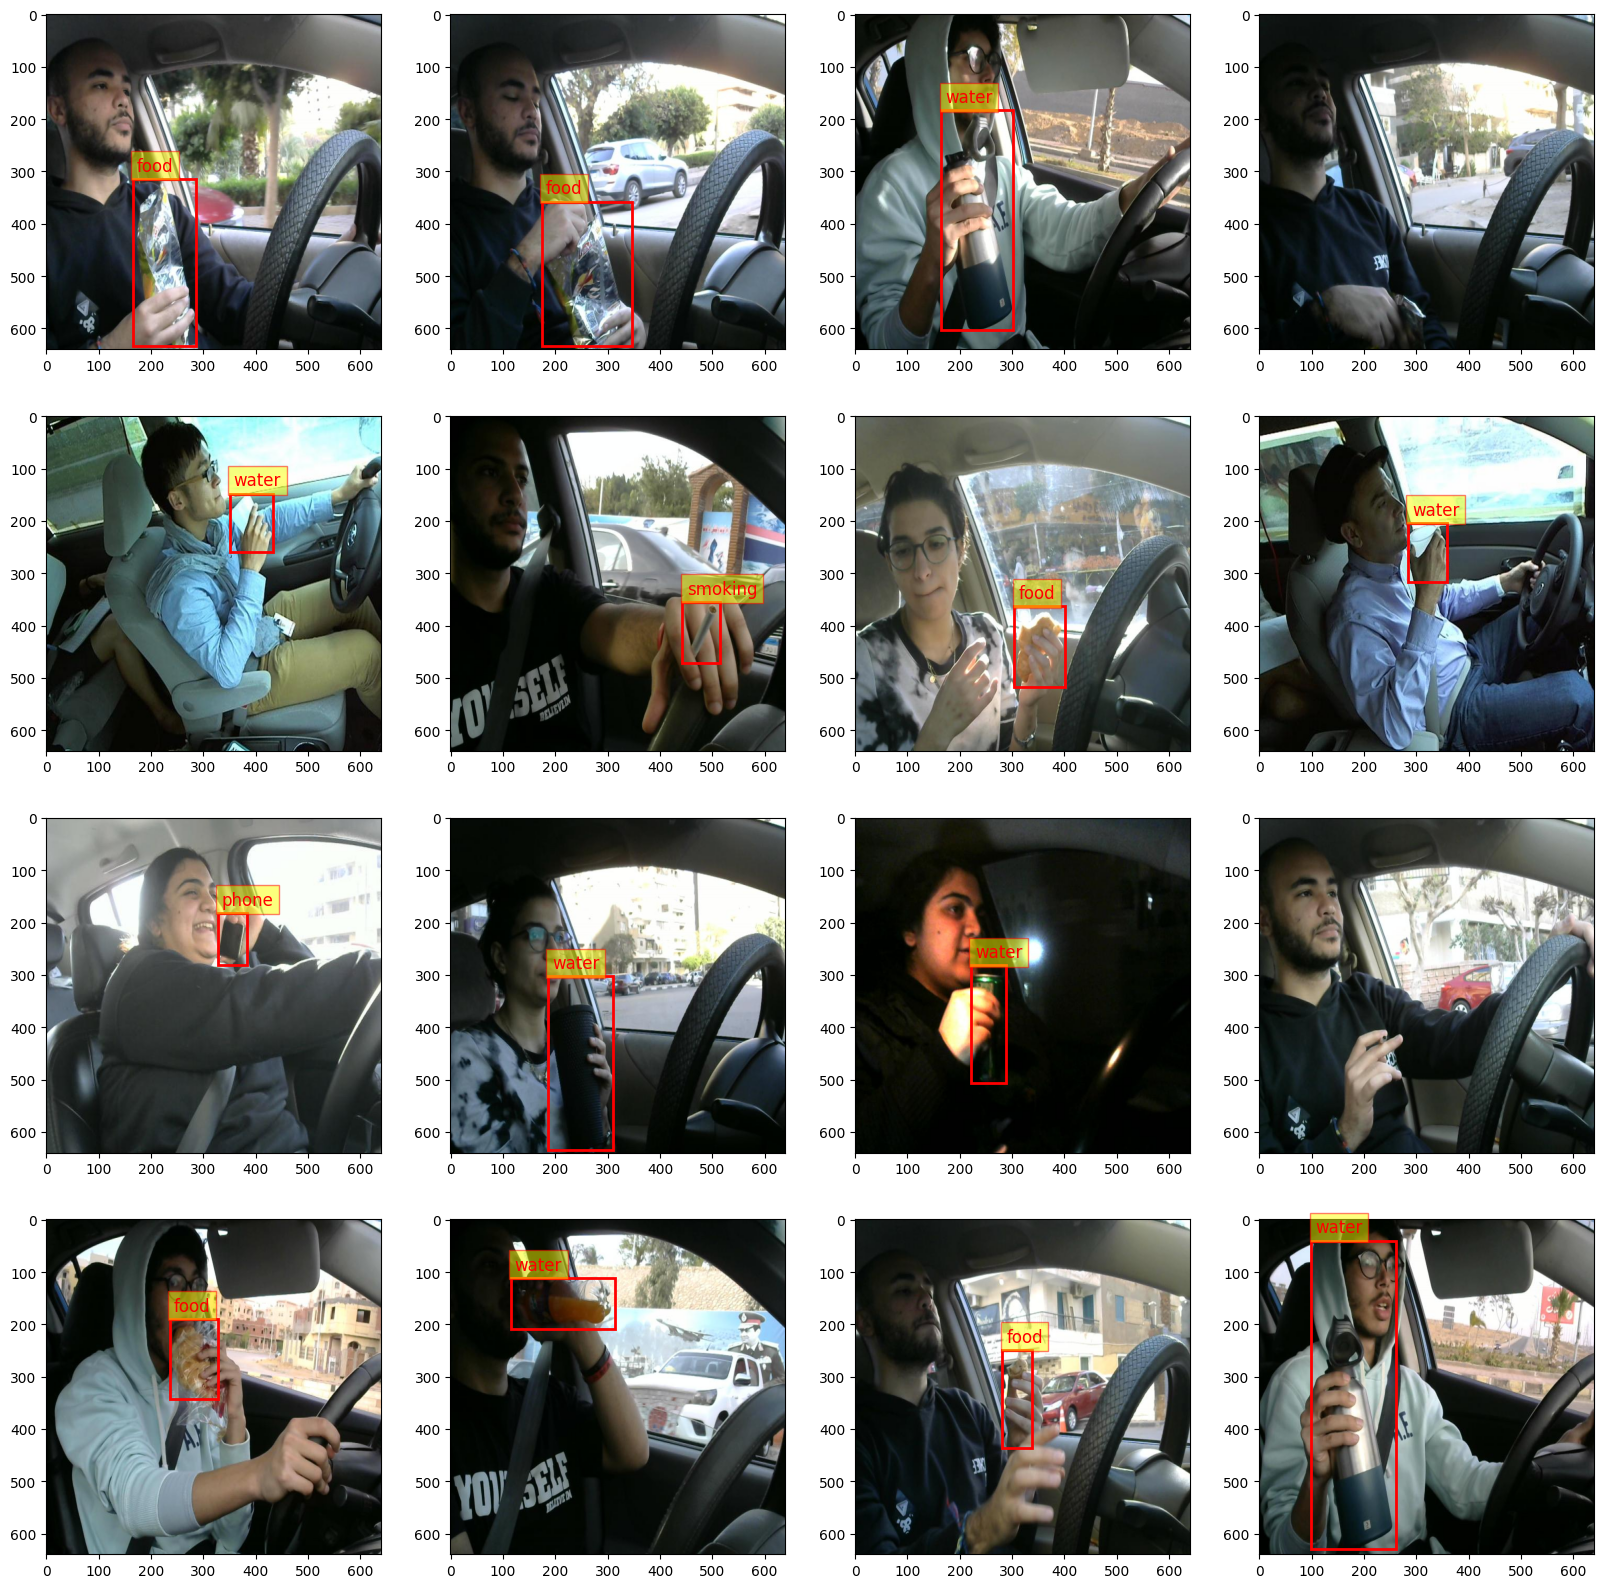

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image,ImageDraw
import random
import os
import torch
import torchvision
from torchvision.transforms import transforms


# # Step 1: Recreate the model architecture
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# # Step 3: Load Pretrained Model and Modify for Custom Classes
num_classes = 4  
weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(weights=weights)
# # Replace the classification head
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes + 1)

model.load_state_dict(torch.load("fasterRCNN.pth"))
# Assuming `model` and `test_data_loader` are already defined
model.eval()  # Set the model to evaluation mode
model.to(device)  # Ensure the model is on the correct device

# Create the plot
fig, ax = plt.subplots(4, 4, figsize=(20,20))
ax = ax.ravel()

transform = transforms.ToTensor()

test_dir = "../data/mobile detection.v7i.yolov11/test/images"
test_list_file = os.listdir(test_dir)
# font = ImageFont.truetype("arial.ttf", 28)


class_names = ['background', 'water', 'food', 'phone', 'smoking']

for idx in range(16):
    # Prepare the image
    img_path = os.path.join(test_dir,random.choice(test_list_file))
    image = Image.open(img_path)
    image = transform(image)
    image_tensor = image.unsqueeze(0).to(device)  # Add a batch dimension

    # Get predictions
    with torch.no_grad():
        prediction = model(image_tensor)[0]  # Get the first image's predictions

    print(prediction)

    # Convert image to numpy for visualization
    image_np = image.cpu().permute(1, 2, 0).numpy()  # Convert (C, H, W) -> (H, W, C)

    # Extract predictions
    boxes = prediction["boxes"].cpu().numpy()
    labels = prediction["labels"].cpu().numpy()
    scores = prediction["scores"].cpu().numpy()

    ax[idx].imshow(image_np)

    img = Image.open(img_path)
    colors = [(255,0,0),(0,255,0),(0,0,255),(255,0,255),(255,255,0),(0,255,255),(255,140,0),(0,128,0)]

    # Add bounding boxes to the image
    for box, label, score in zip(boxes, labels, scores):
        if score >= 0.8:
            xmin, ymin, xmax, ymax = box
            width, height = xmax - xmin, ymax - ymin
            rect = patches.Rectangle(
                (xmin, ymin),
                width,
                height,
                linewidth=2,
                edgecolor="red",
                facecolor="none",
            )
            ax[idx].add_patch(rect)
            ax[idx].text(
                xmin + 8,
                ymin - 16,
                f"{class_names[label]}",
                color="red",
                fontsize=12,
                bbox=dict(facecolor="yellow", alpha=0.5, edgecolor="red"),
            )
            color = random.choice(colors)
            img1 = ImageDraw.Draw(img)
            img1.rectangle([(int(xmin),int(ymin)),(int(xmax),int(ymax))],outline=color,width=4)
            img1.text((int(xmin),int(ymin-30)), "Bear", fill=color)
            # img.save(f'img/image_{idx}.png')


# Display the image with bounding boxes
plt.show()